# RealEstate AI — House Price Prediction

## Objective

Build a machine learning system that predicts real estate prices
using property-related features.

## Machine Learning Model

Linear Regression

check data

Phase 1

In [1]:
import pandas as pd

cell 2:
    Load dataset

In [4]:
file_path = "../data/realtor-data.zip.csv"
df = pd.read_csv(file_path)


cell 3:
    Dataset first look

In [5]:
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [6]:
df.shape

(2226382, 12)

In [7]:
df.columns

Index(['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street',
       'city', 'state', 'zip_code', 'house_size', 'prev_sold_date'],
      dtype='str')

In [8]:
#datatypes
df.dtypes

brokered_by       float64
status                str
price             float64
bed               float64
bath              float64
acre_lot          float64
street            float64
city                  str
state                 str
zip_code          float64
house_size        float64
prev_sold_date        str
dtype: object

In [ ]:
#Basic information

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          str    
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            str    
 8   state           str    
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  str    
dtypes: float64(8), str(4)
memory usage: 203.8 MB


In [10]:
#statistical summary
df.describe()

,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,2.221849e+06,2.224841e+06,1.745065e+06,1.714611e+06,1.900793e+06,2.215516e+06,2.226083e+06,1.657898e+06
mean,5.293989e+04,5.241955e+05,3.275841e+00,2.496440e+00,1.522303e+01,1.012325e+06,5.218668e+04,2.714471e+03
std,3.064275e+04,2.138893e+06,1.567274e+00,1.652573e+00,7.628238e+02,5.837635e+05,2.895408e+04,8.081635e+05
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
25%,2.386100e+04,1.650000e+05,3.000000e+00,2.000000e+00,1.500000e-01,5.063128e+05,2.961700e+04,1.300000e+03
50%,5.288400e+04,3.250000e+05,3.000000e+00,2.000000e+00,2.600000e-01,1.012766e+06,4.838200e+04,1.760000e+03
75%,7.918300e+04,5.500000e+05,4.000000e+00,3.000000e+00,9.800000e-01,1.521173e+06,7.807000e+04,2.413000e+03
max,1.101420e+05,2.147484e+09,4.730000e+02,8.300000e+02,1.000000e+05,2.001357e+06,9.999900e+04,1.040400e+09


In [11]:
#for missing values checking
df.isnull().sum()

brokered_by         4533
status                 0
price               1541
bed               481317
bath              511771
acre_lot          325589
street             10866
city                1407
state                  8
zip_code             299
house_size        568484
prev_sold_date    734297
dtype: int64

Phase 2:

In [12]:
#missing percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

prev_sold_date    32.981627
house_size        25.533983
bath              22.986666
bed               21.618797
acre_lot          14.624130
street             0.488056
brokered_by        0.203604
price              0.069215
city               0.063197
zip_code           0.013430
state              0.000359
status             0.000000
dtype: float64

In [14]:
df.shape

(2226382, 12)

In [15]:
#duplicate rows
df.duplicated().sum()

np.int64(0)

In [16]:
df.dtypes

brokered_by       float64
status                str
price             float64
bed               float64
bath              float64
acre_lot          float64
street            float64
city                  str
state                 str
zip_code          float64
house_size        float64
prev_sold_date        str
dtype: object

In [17]:
#for understanding categorical columns
print("Status:")
print(df["status"].value_counts())

print("\nState:")
print(df["state"].nunique())

print("\nCity:")
print(df["city"].nunique())

Status:
status
for_sale          1389306
sold               812009
ready_to_build      25067
Name: count, dtype: int64

State:
55

City:
20098


In [ ]:
#check numerical values sanity
df[["price", "bed", "bath", "acre_lot", "house_size"]].describe()

,price,bed,bath,acre_lot,house_size
count,2.224841e+06,1.745065e+06,1.714611e+06,1.900793e+06,1.657898e+06
mean,5.241955e+05,3.275841e+00,2.496440e+00,1.522303e+01,2.714471e+03
std,2.138893e+06,1.567274e+00,1.652573e+00,7.628238e+02,8.081635e+05
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,4.000000e+00
25%,1.650000e+05,3.000000e+00,2.000000e+00,1.500000e-01,1.300000e+03
50%,3.250000e+05,3.000000e+00,2.000000e+00,2.600000e-01,1.760000e+03
75%,5.500000e+05,4.000000e+00,3.000000e+00,9.800000e-01,2.413000e+03
max,2.147484e+09,4.730000e+02,8.300000e+02,1.000000e+05,1.040400e+09


In [19]:
# actual investigation
print("Price <= 0:", (df["price"] <= 0).sum())
print("Beds > 20:", (df["bed"] > 20).sum())
print("Baths > 20:", (df["bath"] > 20).sum())
print("Acre lot > 100:", (df["acre_lot"] > 100).sum())
print("House size > 10000:", (df["house_size"] > 10000).sum())

Price <= 0: 280
Beds > 20: 725
Baths > 20: 401
Acre lot > 100: 18166
House size > 10000: 4213


In [20]:
#Huge bedrooms
df[df["bed"] > 20][
    ["price", "bed", "bath", "acre_lot", "house_size", "city", "state"]
].head(10)
#Huge bathrooms
df[df["bed"] > 20][
    ["price", "bed", "bath", "acre_lot", "house_size", "city", "state"]
].head(10)
#Huge House sizes
df[df["house_size"] > 10000][
    ["price", "bed", "bath", "acre_lot", "house_size", "city", "state"]
].head(10)

,price,bed,bath,acre_lot,house_size,city,state
42,400000.0,NaN,NaN,0.99,43082.0,Moca,Puerto Rico
303,2500000.0,6.0,8.0,9.65,10244.0,Cabo Rojo,Puerto Rico
346,435000.0,3.0,3.0,0.36,20132.0,Sabana Grande,Puerto Rico
372,108000.0,4.0,1.0,0.94,13818.0,Utuado,Puerto Rico
706,400000.0,7.0,4.0,0.39,17198.0,Mayaguez,Puerto Rico
892,2500000.0,NaN,NaN,0.27,10225.0,Rincon,Puerto Rico
1188,98400.0,3.0,3.0,0.17,14000.0,Cidra,Puerto Rico
1601,191000.0,4.0,3.0,0.09,19000.0,Gurabo,Puerto Rico
1962,1500000.0,NaN,NaN,6.00,27591.0,Caguas,Puerto Rico
2254,8250000.0,5.0,6.0,33.29,1450112.0,Culebra,Puerto Rico


In [21]:
df[df["bed"] > 20][
    ["price", "bed", "bath", "acre_lot", "house_size", "city", "state"]
].head(20)

,price,bed,bath,acre_lot,house_size,city,state
2968,13995000.0,33.0,35.0,0.09,15000.0,San Juan,Puerto Rico
3771,900000.0,24.0,9.0,0.13,9999.0,Chicopee,Massachusetts
3812,1500000.0,28.0,16.0,0.13,9999.0,Holyoke,Massachusetts
8076,12500000.0,33.0,15.0,89.00,20821.0,Lenox,Massachusetts
8621,2850000.0,40.0,36.0,1.78,27443.0,Claverack,New York
8754,1350000.0,21.0,25.0,9.90,14500.0,Litchfield,Connecticut
10258,2200000.0,21.0,14.0,31.98,25106.0,Millbrook,New York
12088,15150000.0,86.0,56.0,1.32,35666.0,Framingham,Massachusetts
12182,450000.0,31.0,14.0,1.61,13000.0,Blackstone,Massachusetts
14226,1200000.0,27.0,9.0,0.11,10250.0,Central Falls,Rhode Island


In [22]:
df[["bed", "bath", "house_size"]].corr()


,bed,bath,house_size
bed,1.000000,0.611708,0.189682
bath,0.611708,1.000000,0.223767
house_size,0.189682,0.223767,1.000000


In [23]:

df["prev_sold_date"].dropna().head(10)

411     2020-02-28
502     2019-06-28
1025    2021-09-15
1160    2021-03-15
2270    2013-10-11
2277    2018-04-05
2493    2016-04-28
2555    2016-11-16
3062    2010-01-26
3213    2022-03-18
Name: prev_sold_date, dtype: str

In [24]:
df["prev_sold_date"].dropna().tail(10)


2226372    2022-02-14
2226373    2022-02-11
2226374    2022-02-11
2226375    2022-03-28
2226376    2022-03-28
2226377    2022-03-25
2226378    2022-03-25
2226379    2022-03-24
2226380    2022-03-24
2226381    2022-03-23
Name: prev_sold_date, dtype: str

In [25]:
pd.to_datetime(df["prev_sold_date"])

0                NaT
1                NaT
2                NaT
3                NaT
4                NaT
             ...    
2226377   2022-03-25
2226378   2022-03-25
2226379   2022-03-24
2226380   2022-03-24
2226381   2022-03-23
Name: prev_sold_date, Length: 2226382, dtype: datetime64[us]

----------------------------------------------------------------------
----------------------------------------------------------------------

             Phase 3: Data Cleaning

--------------------------------------------------------------------------------------------------------------------------------------------

In [26]:
df_clean = df.copy()

In [27]:
df_clean = df_clean.dropna(subset=["price"])

In [29]:
df_clean["price"].isnull().sum()

np.int64(0)

In [30]:
df_clean[df_clean["price"] <= 0][
    ["price", "bed", "bath", "acre_lot", "house_size", "city", "state"]
].head(20)

,price,bed,bath,acre_lot,house_size,city,state
46207,0.0,NaN,NaN,0.17,4500.0,Paterson,New Jersey
46208,0.0,NaN,NaN,0.22,5000.0,Paterson,New Jersey
49607,0.0,4.0,4.0,NaN,NaN,New York,New York
57803,0.0,NaN,NaN,NaN,NaN,Jersey City,New Jersey
116304,0.0,NaN,1.0,NaN,NaN,Queens,New York
286067,0.0,2.0,NaN,NaN,2114.0,Cary,North Carolina
286068,0.0,2.0,NaN,NaN,1776.0,Cary,North Carolina
286069,0.0,2.0,NaN,NaN,1888.0,Cary,North Carolina
286070,0.0,2.0,NaN,NaN,1519.0,Cary,North Carolina
286072,0.0,2.0,NaN,NaN,2058.0,Cary,North Carolina


In [31]:
df_clean = df_clean[df_clean["price"] > 0]

In [32]:
#verify
print("Rows remaining:", len(df_clean))
print("Price <= 0:", (df_clean["price"] <= 0).sum())


Rows remaining: 2224561
Price <= 0: 0


In [34]:
df_clean = df_clean.dropna()

In [36]:
#verify
print("Rows remaining:", len(df_clean))
print("Total missing values:", df_clean.isnull().sum().sum())

Rows remaining: 1084909
Total missing values: 0


In [37]:
#outliers
df_clean[["price", "bed", "bath", "acre_lot", "house_size"]].describe()

,price,bed,bath,acre_lot,house_size
count,1.084909e+06,1.084909e+06,1.084909e+06,1.084909e+06,1.084909e+06
mean,5.687041e+05,3.363451e+00,2.519739e+00,1.195407e+01,2.074974e+03
std,1.181611e+06,1.363310e+00,1.305497e+00,7.953078e+02,2.767609e+03
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+02
25%,2.400000e+05,3.000000e+00,2.000000e+00,1.400000e-01,1.347000e+03
50%,3.800000e+05,3.000000e+00,2.000000e+00,2.100000e-01,1.792000e+03
75%,6.000000e+05,4.000000e+00,3.000000e+00,4.100000e-01,2.438000e+03
max,5.150000e+08,4.440000e+02,2.220000e+02,1.000000e+05,1.560780e+06


In [38]:
Q1 = df_clean["price"].quantile(0.25)
Q3 = df_clean["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("Potential price outliers:",
      ((df_clean["price"] < lower_bound) |
       (df_clean["price"] > upper_bound)).sum())

Q1: 240000.0
Q3: 600000.0
IQR: 360000.0
Lower bound: -300000.0
Upper bound: 1140000.0
Potential price outliers: 89278


In [39]:
df_clean[df_clean["price"] > 1140000][
    ["price", "bed", "bath", "acre_lot", "house_size", "city", "state"]
].head(20)

,price,bed,bath,acre_lot,house_size,city,state
2277,6899000.0,4.0,6.0,0.83,4600.0,Saint Thomas,Virgin Islands
3693,1295000.0,4.0,5.0,7.81,7000.0,Hadley,Massachusetts
3703,1390000.0,3.0,5.0,14.48,3112.0,Williamsburg,Massachusetts
3777,1290000.0,5.0,5.0,2.00,4476.0,Williamsburg,Massachusetts
3867,1500000.0,6.0,7.0,4.52,6250.0,South Hadley,Massachusetts
3897,1237542.0,4.0,3.0,100.50,3063.0,Blandford,Massachusetts
4166,2995000.0,4.0,8.0,12.10,14240.0,Worthington,Massachusetts
4286,1390000.0,14.0,15.0,2.40,10302.0,Great Barrington,Massachusetts
4379,2100000.0,3.0,3.0,5.20,2900.0,Great Barrington,Massachusetts
4402,1745000.0,6.0,6.0,40.10,7268.0,Norfolk,Connecticut


In [40]:
for column in ["bed", "bath", "acre_lot", "house_size"]:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df_clean[column] < lower) | (df_clean[column] > upper)).sum()

    print(f"\n{column}")
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Potential outliers:", outliers)


bed
Lower bound: 1.5
Upper bound: 5.5
Potential outliers: 48125

bath
Lower bound: 0.5
Upper bound: 4.5
Potential outliers: 50309

acre_lot
Lower bound: -0.2649999999999999
Upper bound: 0.815
Potential outliers: 166403

house_size
Lower bound: -289.5
Upper bound: 4074.5
Potential outliers: 52727


In [41]:
df_clean[
    (df_clean["bed"] > 20) |
    (df_clean["bath"] > 20) |
    (df_clean["acre_lot"] > 100) |
    (df_clean["house_size"] > 10000)
][
    ["price", "bed", "bath", "acre_lot", "house_size", "city", "state"]
].head(30)

,price,bed,bath,acre_lot,house_size,city,state
3897,1237542.0,4.0,3.0,100.50,3063.0,Blandford,Massachusetts
4166,2995000.0,4.0,8.0,12.10,14240.0,Worthington,Massachusetts
4286,1390000.0,14.0,15.0,2.40,10302.0,Great Barrington,Massachusetts
4495,239000.0,20.0,18.0,0.71,15096.0,Pittsfield,Massachusetts
4516,999000.0,4.0,4.0,196.10,3396.0,Lanesborough,Massachusetts
4951,15500000.0,3.0,5.0,298.00,4273.0,New Marlborough,Massachusetts
5180,3850000.0,5.0,8.0,9.07,10823.0,Farmington,Connecticut
5259,5995000.0,4.0,5.0,115.00,6964.0,Avon,Connecticut
6481,1495000.0,15.0,9.0,0.19,14532.0,Worcester,Massachusetts
6779,1450000.0,3.0,3.0,134.40,2600.0,Halifax,Vermont


In [42]:
print("Beds < 1:", (df_clean["bed"] < 1).sum())
print("Baths < 1:", (df_clean["bath"] < 1).sum())
print("Acre lot < 0:", (df_clean["acre_lot"] < 0).sum())
print("House size <= 0:", (df_clean["house_size"] <= 0).sum())
print("Price <= 0:", (df_clean["price"] <= 0).sum())

Beds < 1: 0
Baths < 1: 0
Acre lot < 0: 0
House size <= 0: 0
Price <= 0: 0


In [43]:
df_clean["prev_sold_date"].head(10)

502     2019-06-28
2270    2013-10-11
2277    2018-04-05
3409    2014-06-25
3410    2012-10-12
3416    1986-11-20
3423    2008-09-19
3430    2005-07-25
3436    1992-06-24
3438    1996-07-12
Name: prev_sold_date, dtype: str

In [44]:
df_clean["prev_sold_date"].tail(10)

2226372    2022-02-14
2226373    2022-02-11
2226374    2022-02-11
2226375    2022-03-28
2226376    2022-03-28
2226377    2022-03-25
2226378    2022-03-25
2226379    2022-03-24
2226380    2022-03-24
2226381    2022-03-23
Name: prev_sold_date, dtype: str

In [45]:
#Dataa cleaning Complete
df_clean = df.copy()

df_clean = df_clean.dropna(subset=["price"])

df_clean = df_clean[df_clean["price"] > 0]

df_clean = df_clean.dropna()

print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Rows: 1084909
Columns: 12
Missing values: 0
Duplicate rows: 0


--------------------------------------------------------------------------------------------------------------------------------------------

 Phase 4 : EDA

--------------------------------------------------------------------------------------------------------------------------------------------

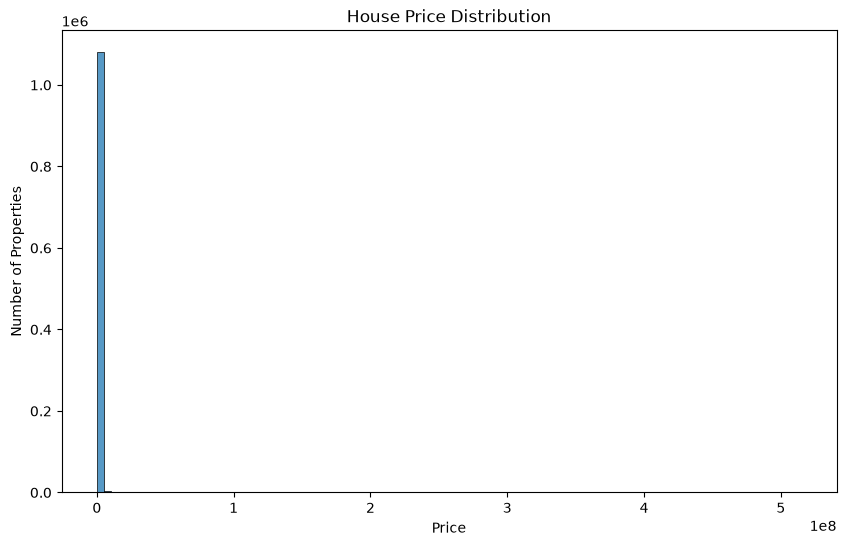

In [46]:
#price distribution visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_clean["price"], bins=100)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Properties")
plt.show()

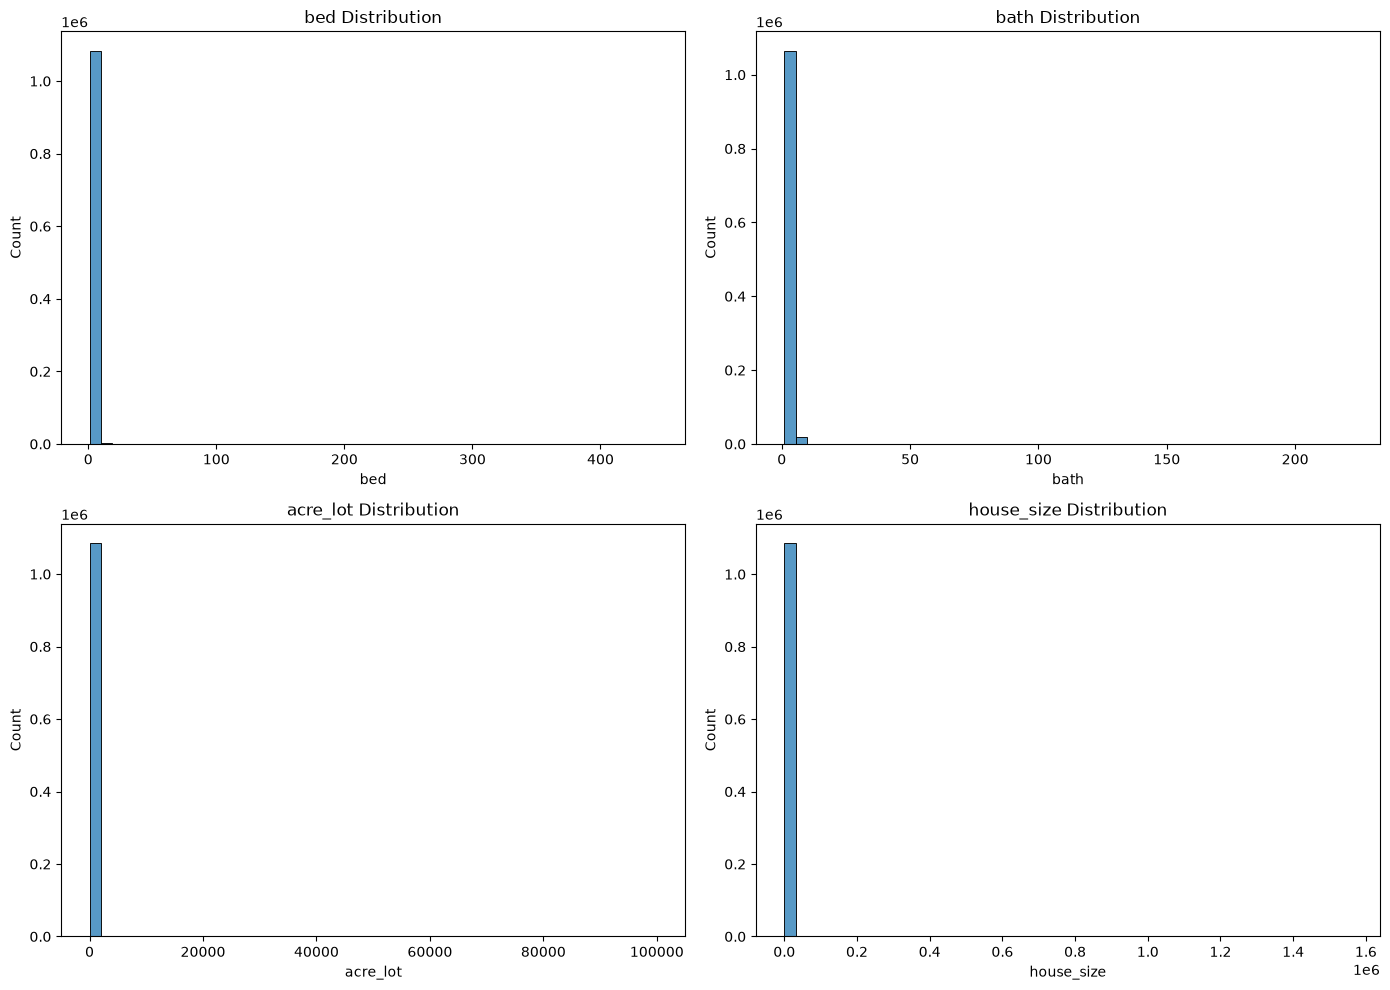

In [47]:
numeric_cols = ["bed", "bath", "acre_lot", "house_size"]

plt.figure(figsize=(14, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_clean[col], bins=50)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

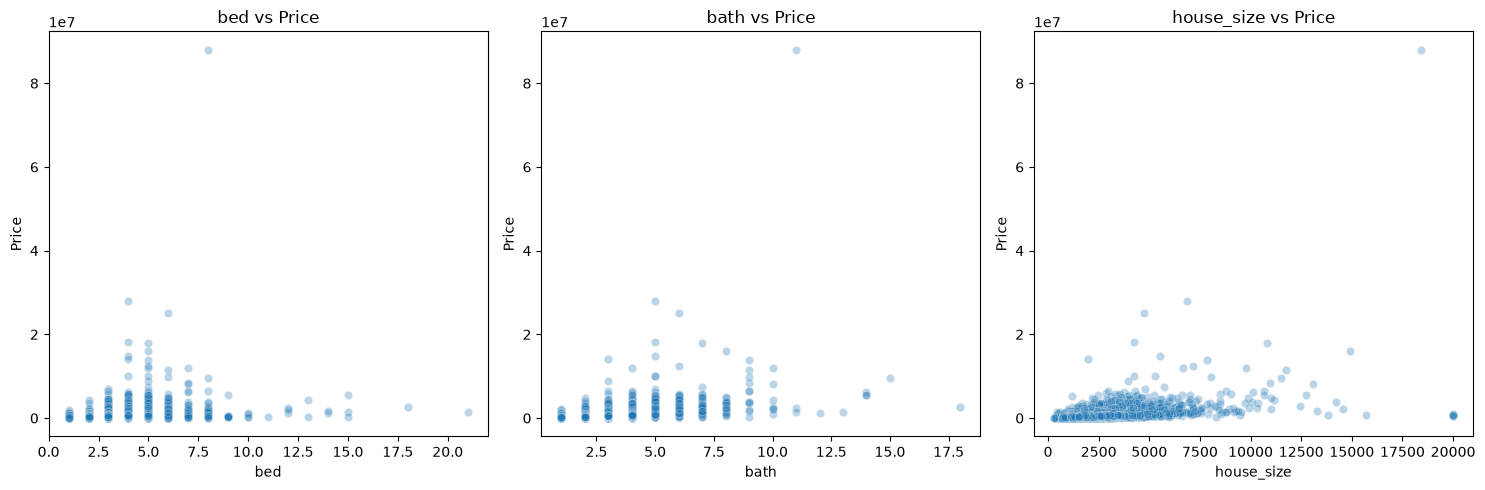

In [48]:
# features vs house price visualization
features = ["bed", "bath", "house_size"]

plt.figure(figsize=(15, 5))

for i, col in enumerate(features, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(
        data=df_clean.sample(10000, random_state=42),
        x=col,
        y="price",
        alpha=0.3
    )
    plt.title(f"{col} vs Price")
    plt.xlabel(col)
    plt.ylabel("Price")

plt.tight_layout()
plt.show()


In [49]:
#correlation analysis
corr_cols = ["price", "bed", "bath", "acre_lot", "house_size"]

correlation = df_clean[corr_cols].corr()

print(correlation)

               price       bed      bath  acre_lot  house_size
price       1.000000  0.205024  0.373092  0.000815    0.187705
bed         0.205024  1.000000  0.685355 -0.000250    0.239807
bath        0.373092  0.685355  1.000000 -0.001426    0.316937
acre_lot    0.000815 -0.000250 -0.001426  1.000000   -0.000010
house_size  0.187705  0.239807  0.316937 -0.000010    1.000000


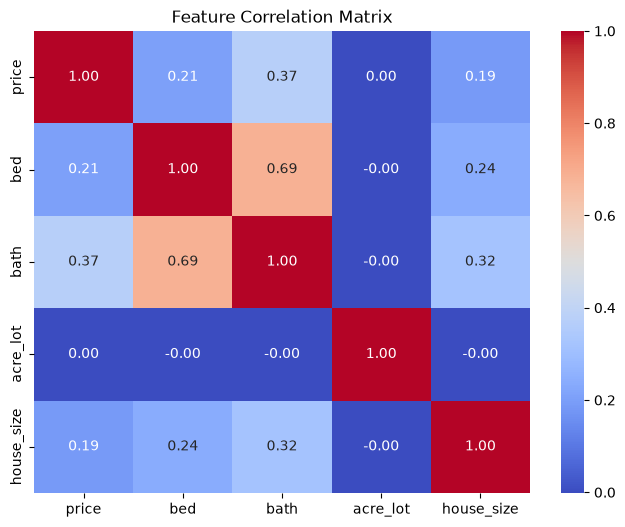

In [50]:
#heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [51]:
#Categorical Features Analysis
# property status
status_counts = df_clean["status"].value_counts()

print(status_counts)

status
sold        606926
for_sale    477983
Name: count, dtype: int64


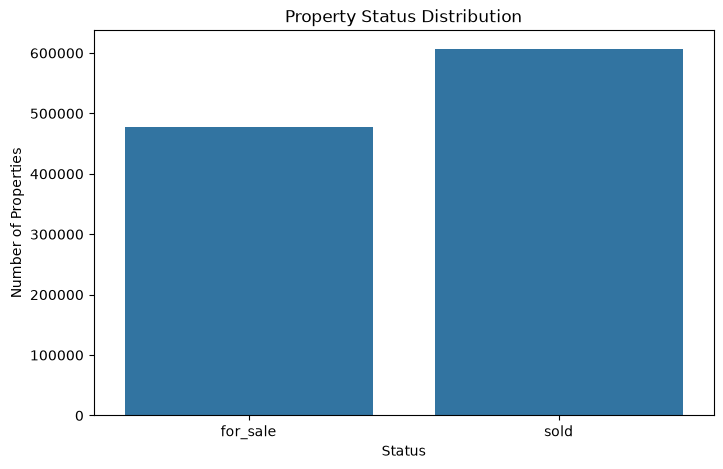

In [52]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="status"
)

plt.title("Property Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Properties")
plt.show()

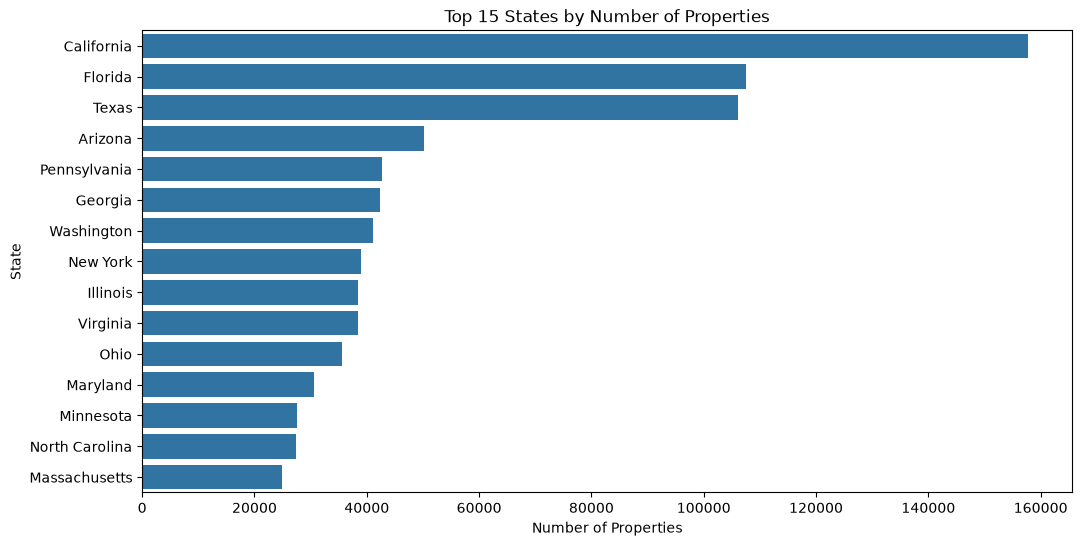

In [54]:
top_states = df_clean["state"].value_counts().head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 15 States by Number of Properties")
plt.xlabel("Number of Properties")
plt.ylabel("State")
plt.show()

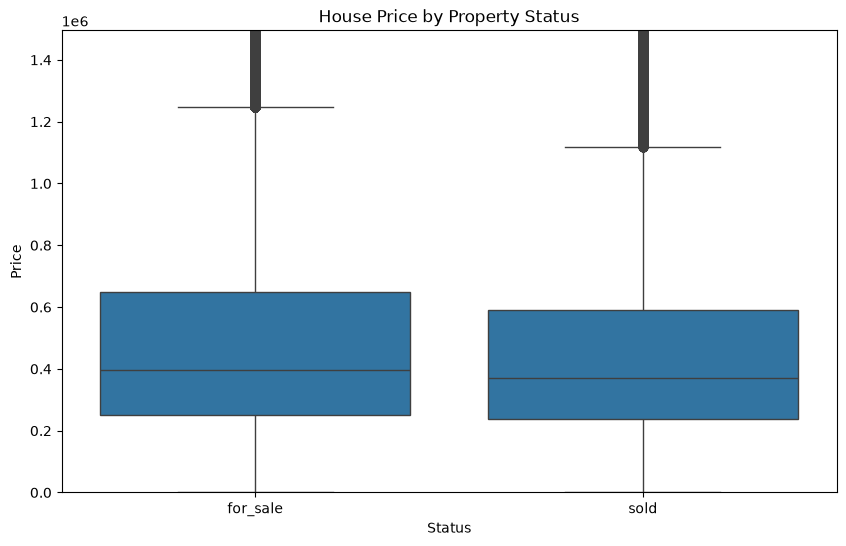

In [55]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="status",
    y="price"
)

plt.title("House Price by Property Status")
plt.xlabel("Status")
plt.ylabel("Price")
plt.ylim(0, df_clean["price"].quantile(0.95))

plt.show()

phase 4:

    Feature engineering

In [56]:
#simple linear regression model
features = ["bed", "bath", "acre_lot", "house_size"]

X = df_clean[features]
y = df_clean["price"]

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['bed', 'bath', 'acre_lot', 'house_size']
X shape: (1084909, 4)
y shape: (1084909,)


In [57]:
#Data  feature engineering
df_clean["prev_sold_date"] = pd.to_datetime(
    df_clean["prev_sold_date"]
)

df_clean["prev_sold_year"] = df_clean["prev_sold_date"].dt.year

print(df_clean[["prev_sold_date", "prev_sold_year"]].head())

     prev_sold_date  prev_sold_year
502      2019-06-28            2019
2270     2013-10-11            2013
2277     2018-04-05            2018
3409     2014-06-25            2014
3410     2012-10-12            2012


In [58]:
#check
print(df_clean["prev_sold_year"].value_counts().sort_index())

prev_sold_year
1901         1
1904         1
1905         1
1909         2
1910         1
         ...  
2021    237545
2022    451541
2023       493
2024         3
2026         1
Name: count, Length: 84, dtype: int64


In [59]:
# final feature preparing
features = [
    "bed",
    "bath",
    "acre_lot",
    "house_size",
    "prev_sold_year"
]


X = df_clean[features]
y = df_clean["price"]



print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)


Features: ['bed', 'bath', 'acre_lot', 'house_size', 'prev_sold_year']
X shape: (1084909, 5)
y shape: (1084909,)


In [60]:
print(X.isnull().sum())
print(y.isnull().sum())

bed               0
bath              0
acre_lot          0
house_size        0
prev_sold_year    0
dtype: int64
0


Phase 5:
     Train/Test split
     

In [61]:
#split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
    
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (867927, 5)
X_test: (216982, 5)
y_train: (867927,)
y_test: (216982,)


In [62]:
#linear regression model 
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [63]:
#see learn coefficient
print("Intercept:", model.intercept_)

for feature, coefficient in zip(features, model.coef_):
    print(feature, ":", coefficient)

Intercept: 10838786.911028769
bed : -96176.8273451456
bath : 378638.5155485064
acre_lot : 2.276753564576495
house_size : 32.07221854839008
prev_sold_year : -5436.222795121309


Phase 8:     
    Model Evaluation

In [64]:
y_pred = model.predict(X_test)

print("Predictions generated:", len(y_pred))
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated: 216982
First 10 predictions:
[  71023.63149099  381480.35940082 1166563.51213092  424201.7839542
  664502.64665154  286152.91767518  293004.48454546  473528.33173226
  370784.74811448  852151.34403624]


In [65]:
#Evaluation matrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 341915.61254254606
RMSE: 941328.0147294921
R²  : 0.19903066236750055


Phase 9:

    Model improvement

In [66]:
#log transformation
import numpy as np

X_log = X.copy()

log_features = [
    "acre_lot",
    "house_size"
]

for col in log_features:
    X_log[col] = np.log1p(X_log[col])

y_log = np.log1p(y)

print(X_log.head())
print(y_log.head())

      bed  bath  acre_lot  house_size  prev_sold_year
502   7.0   3.0  0.086178    7.084226            2019
2270  5.0   4.0  0.688135    8.517393            2013
2277  4.0   6.0  0.604316    8.434029            2018
3409  3.0   3.0  0.371564    7.747165            2014
3410  3.0   2.0  0.307485    7.152269            2012
502     11.608245
2270    13.764218
2277    15.746887
3409    13.171155
3410    12.577295
Name: price, dtype: float64


Train Log Model

In [67]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log,
    y_log,
    test_size=0.20,
    random_state=42
)

print("X_train_log:", X_train_log.shape)
print("X_test_log :", X_test_log.shape)

X_train_log: (867927, 5)
X_test_log : (216982, 5)


In [68]:
log_model = LinearRegression()

log_model.fit(X_train_log, y_train_log)

print("Log-transformed model trained!")

Log-transformed model trained!


In [69]:
#prediction
y_pred_log = log_model.predict(X_test_log)

print(y_pred_log[:10])

[12.26242737 12.80186509 13.39525343 13.20552698 12.97518779 12.77287228
 12.82531112 12.6106112  12.7385619  13.04846935]


In [70]:
#Inverse information
y_pred_original = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test_log)

print("First 10 actual prices:")
print(y_test_original.iloc[:10].values)

print("\nFirst 10 predicted prices:")
print(y_pred_original[:10])

First 10 actual prices:
[409900. 760000. 490000. 350000. 425000. 370000. 129900. 425000. 239000.
 725000.]

First 10 predicted prices:
[211593.58149075 362892.64702186 656876.89956319 543358.79437006
 431570.20494192 352522.39944977 371501.5931927  299721.16305913
 340632.33077257 464384.05727469]


In [71]:
#improved model evaluation
mae_log = mean_absolute_error(y_test_original, y_pred_original)

rmse_log = np.sqrt(
    mean_squared_error(y_test_original, y_pred_original)
)

r2_log = r2_score(y_test_original, y_pred_original)

print("Log Model MAE :", mae_log)
print("Log Model RMSE:", rmse_log)
print("Log Model R²  :", r2_log)

Log Model MAE : 19970482973.165775
Log Model RMSE: 9302231757994.516
Log Model R²  : -78218275023097.2


In [72]:
#Model comparison
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Basic Linear Regression": [mae, rmse, r2],
    "Log Linear Regression": [mae_log, rmse_log, r2_log]
})

print(comparison)

  Metric  Basic Linear Regression  Log Linear Regression
0    MAE            341915.612543           1.997048e+10
1   RMSE            941328.014729           9.302232e+12
2     R²                 0.199031          -7.821828e+13


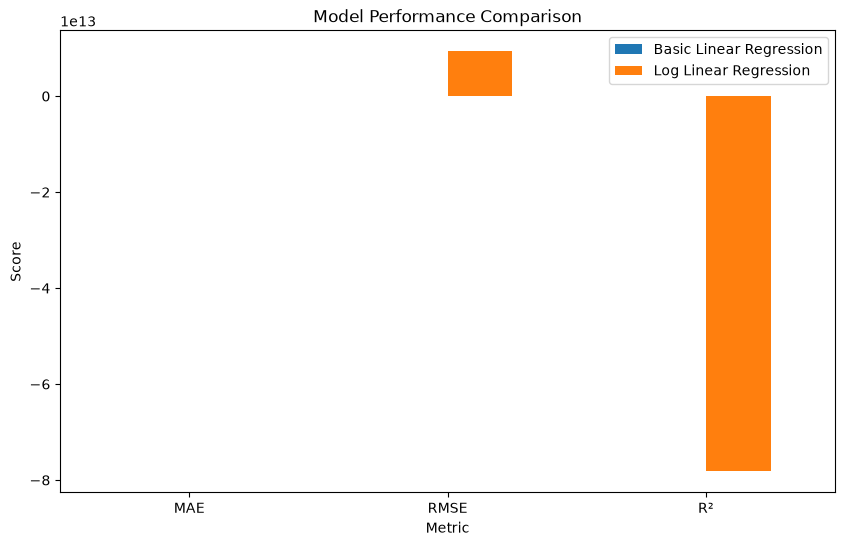

In [73]:
#visualize
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.show()


In [74]:
#Calculate Residential
residuals = y_test - y_pred

print(residuals.head())

1482407    338876.368509
2086205    378519.640599
1113047   -676563.512131
1548311    -74201.783954
1540139   -239502.646652
Name: price, dtype: float64


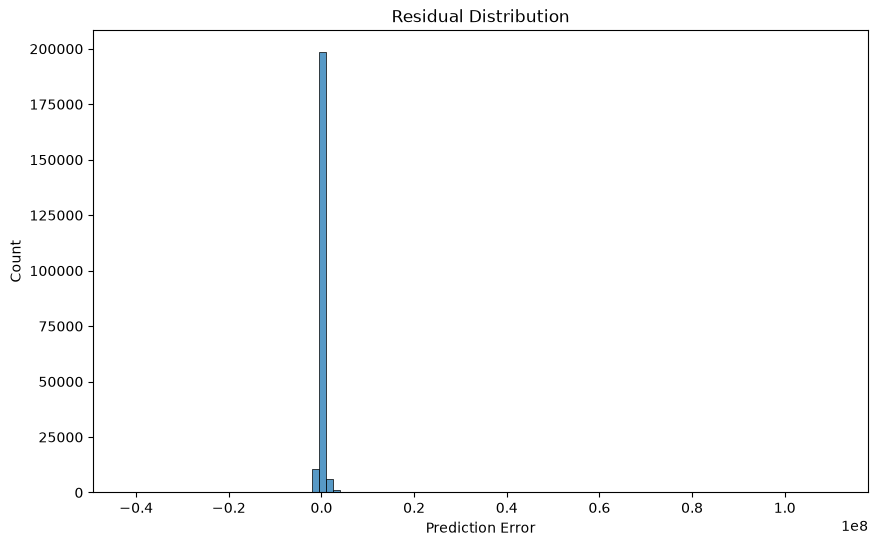

In [75]:
plt.figure(figsize=(10, 6))

sns.histplot(residuals, bins=100)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.show()

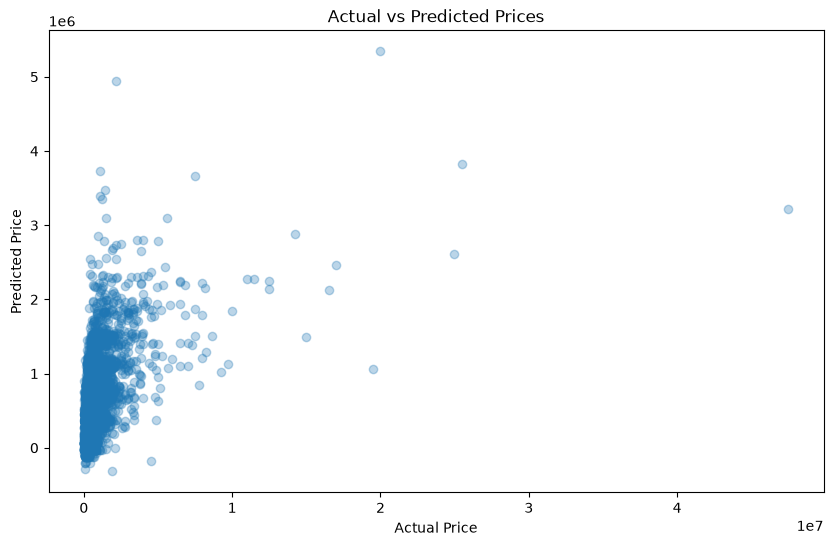

In [76]:
#actual vs predicted
plt.figure(figsize=(10, 6))

sample_idx = np.random.RandomState(42).choice(
    len(y_test),
    size=10000,
    replace=False
)

plt.scatter(
    y_test.iloc[sample_idx],
    y_pred[sample_idx],
    alpha=0.3
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

In [77]:
#model improvement
#one-hot encoding
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "bed",
    "bath",
    "acre_lot",
    "house_size",
    "prev_sold_year"
]

categorical_features = [
    "status",
    "state"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [78]:
#again prepare X
X_improved = df_clean[
    numeric_features + categorical_features
]

y_improved = df_clean["price"]

print(X_improved.shape)
print(y_improved.shape)

(1084909, 7)
(1084909,)


In [79]:
#Preprocessing + Improved Linear Regression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

numeric_features = [
    "bed",
    "bath",
    "acre_lot",
    "house_size",
    "prev_sold_year"
]

categorical_features = [
    "status",
    "state"
]

X_improved = df_clean[
    numeric_features + categorical_features
]

y_improved = df_clean["price"]

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.20,
    random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

improved_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

improved_model.fit(X_train_imp, y_train_imp)

y_pred_imp = improved_model.predict(X_test_imp)

print("Improved model trained!")
print("Predictions:", len(y_pred_imp))

Improved model trained!
Predictions: 216982


In [80]:
#Evaluation + Model Comparison
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_imp = mean_absolute_error(y_test_imp, y_pred_imp)
rmse_imp = np.sqrt(mean_squared_error(y_test_imp, y_pred_imp))
r2_imp = r2_score(y_test_imp, y_pred_imp)

comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Basic Linear Regression": [mae, rmse, r2],
    "Improved Linear Regression": [mae_imp, rmse_imp, r2_imp]
})

print(comparison)

  Metric  Basic Linear Regression  Improved Linear Regression
0    MAE            341915.612543               314266.785136
1   RMSE            941328.014729               909373.216913
2     R²                 0.199031                    0.252488


In [81]:
#model saving
import joblib
import os

os.makedirs("../models", exist_ok=True)

model_path = "../models/real_estate_price_model.pkl"

joblib.dump(improved_model, model_path)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: ../models/real_estate_price_model.pkl
